# Training

Run `data_overview.ipynb` first: it builds `data/optical/final_data/annotations.json`
and explains the crop policy, the class definitions and the three leakage
relations the split has to respect.

## The task

The headline task is **binary: Type-1 (skylight) versus everything else.**
Three-class is available through the switch below and is reported as a secondary
result. Three reasons the binary framing is the primary one:

1. **It is the question the paper asks.** Type-1 is Nodjoumi's skylight class by
   definition -- "possible cave entrance ... almost nonvisible bottom". Type-2
   and Type-4 are both pits of *uncertain* connection to anything.
2. **The Type-4 / Type-2 boundary is contaminated.** Type-4 is assigned from the
   *alignment* of a pit with its neighbours, but the annotation covers a single
   pit and the neighbours often fall outside the crop -- sometimes outside the
   tile entirely. A three-class score is therefore partly measuring label noise.
   The baselines below show it: Type-4 and Type-2 account for 339 of 524 errors
   while Type-1 separates cleanly.
3. **Better statistics.** 93 independent skylight groups against 224, rather
   than three thin classes -- at product level Type-4 appears in only 37 groups.

**Expect it to be hard anyway.** Nodjoumi et al. trained Mask R-CNN on this same
labelling and reported "poor results for all the classes", having to merge
classes down to a binary problem before the numbers moved.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import functools
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from model.hirise_dataset import LandformDataset
from model.model import LavaTubeFinder
from model.training_utils import *

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using", DEVICE)

Using cuda


In [2]:
TASK = "binary"          # "binary" (Type-1 vs rest) or "3class"

annotations = pd.read_json("data/optical/final_data/annotations.json")

CLASS_NAMES = {0: "Vertical Pit/Skylight", 1: "Aligned Shallow Pit", 2: "Sloped Pit"}
SKYLIGHT = 0             # category_id of Type-1 in the source labelling

if TASK == "binary":
    # Remapping the label column keeps every other consumer -- grouping,
    # stratification, the dataset -- working unchanged.
    task_annotations = annotations.assign(
        category_id=(annotations["category_id"] == SKYLIGHT).astype(int)
    )
    TASK_NAMES = {0: "other pit", 1: "skylight"}
    POSITIVE = 1
else:
    task_annotations = annotations
    TASK_NAMES = CLASS_NAMES
    POSITIVE = None

N_CLASSES = len(TASK_NAMES)
targets_all = task_annotations["category_id"].to_numpy()

print(f"task: {TASK}  ({N_CLASSES} classes)")
print(pd.Series(targets_all).map(TASK_NAMES).value_counts().to_string())
majority = pd.Series(targets_all).value_counts(normalize=True).max()
print()
print(f"majority class = {majority * 100:.1f}%")

task: binary  (2 classes)
other pit    1221
skylight      625

majority class = 66.1%


## Dataset

`make_dataset(augment)` is the unit passed around from here on. It is called
twice per split -- once augmented for training, once not for validation -- so
the two sides differ **only** in augmentation and never in content.

There is no `torchvision` transform pipeline. The crop is planned and cut per
access (see `data/optical/landform_crops.py`), which is what gives the
positional augmentation, and the result is already a fixed-size float tensor.

In [3]:
OUT_PX = 384
CONTEXT = 1.75
THERMAL_WINDOW = 32          # stored windows are 32 px; smaller is a centred slice

# Real THEMIS windows, or the torch.randn placeholder. Keep the placeholder
# available: it is the control that says the fusion head gains nothing from
# noise, and "thermal" must land at the majority class under it.
USE_REAL_THERMAL = True

WINDOWS_DIR = "data/thermal/themis_data/windows"
annotation_sites = pd.read_csv("data/thermal/annotation_sites.csv")

# annotation_sites is built from this same table in this same order. Assert it
# rather than trust it: a silent misalignment would pair every landform with
# another landform's thermal window and still train perfectly happily.
assert (annotation_sites["image_name"].to_numpy()
        == annotations["image_name"].to_numpy()).all(),     "annotation_sites.csv is out of step with annotations.json; rebuild it"

thermal_kwargs = (
    dict(thermal_sites=annotation_sites["site_id"].tolist(),
         thermal_dir=WINDOWS_DIR, thermal_window=THERMAL_WINDOW)
    if USE_REAL_THERMAL else dict(thermal_window=THERMAL_WINDOW)
)

# The unit every splitter takes: a dataset over the *full* annotation table,
# differing only in whether it augments.
def make_dataset(augment, load_optical=True):
    return LandformDataset(
        task_annotations, root_dir=".", out_px=OUT_PX, context=CONTEXT,
        augment=augment, load_optical=load_optical, **thermal_kwargs,
    )

train_loader, val_loader = create_dataloaders(
    make_dataset, batch_size=8, num_workers=0, group_level="product"
)
print(f"{len(train_loader.dataset)} train / {len(val_loader.dataset)} val samples")

images, thermals, batch_targets = next(iter(train_loader))
print(f"images   {tuple(images.shape)}  {images.dtype}  "
      f"range [{images.min():.2f}, {images.max():.2f}]")
print(f"thermals {tuple(thermals.shape)}  "
      f"({'real THEMIS' if USE_REAL_THERMAL else 'randn placeholder'}; "
      "channel 0 temperature, channel 1 validity mask)")
if USE_REAL_THERMAL:
    print(f"         mask coverage in this batch: {thermals[:, :, 1].mean():.2f}")
print(f"targets  {batch_targets.tolist()}")

1407 train / 439 val samples
images   (8, 1, 384, 384)  torch.float32  range [0.00, 1.00]
thermals (8, 3, 2, 32, 32)  (real THEMIS; channel 0 temperature, channel 1 validity mask)
         mask coverage in this batch: 0.90
targets  [1, 1, 0, 0, 1, 0, 0, 1]


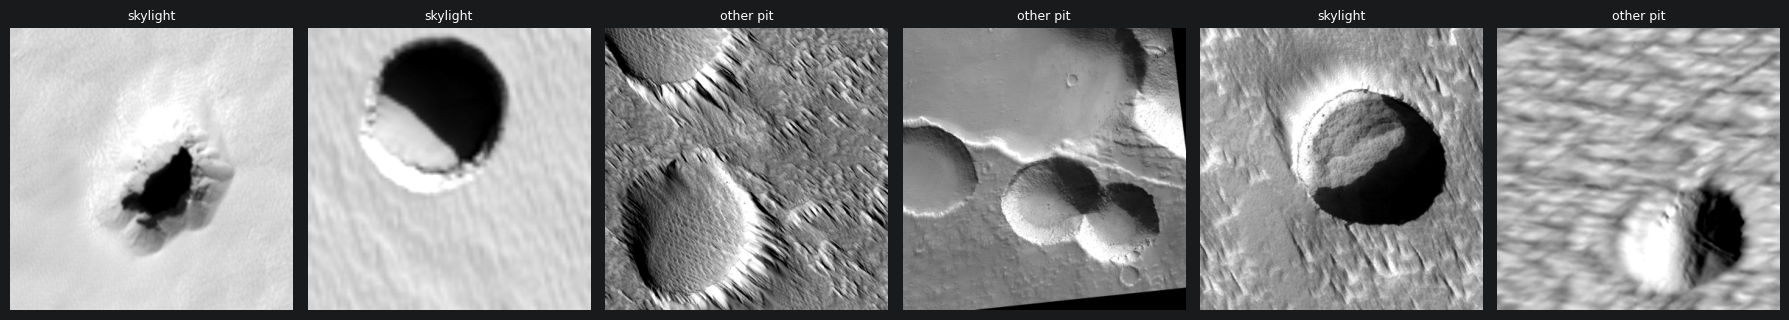

In [4]:
# What the model actually sees, straight off the training loader.
fig, axs = plt.subplots(1, 6, figsize=(18, 3.4))
for ax, image, target in zip(axs, images, batch_targets):
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(TASK_NAMES[int(target)], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Baselines: what is obtainable without morphology

A CNN score means nothing on its own. The bar is not chance, and not the
majority class -- it is *whatever this data set gives up without any shape
information at all*. On an earlier version of this task that number was 97.9%,
and every point of it came from the pipeline rather than the model.

| baseline | what it may look at |
|---|---|
| `majority` | nothing; predicts the commonest training class |
| `histogram` | the crop's intensity histogram: moments, percentiles, dark/bright fractions, entropy |
| `texture` | the above plus gradient-magnitude statistics |
| `illumination` | solar incidence / emission / phase angle, season, local solar time of the source product |
| `metadata` (oracle) | resolution, tile size, annotated diameter, latitude, longitude |

**Why `histogram` is the honest bar.** Every feature in it is a function of the
*multiset* of pixel values, so it is invariant to permuting the pixels. Shuffle a
crop and its morphology is destroyed while these numbers do not move. Anything
this baseline reaches is therefore reachable with literally zero shape
information.

**`metadata` is a disclosure, not a result.** `diameter_m` comes from the
annotation itself, so no real detector would have it before detecting anything.
It measures how much of the label lives outside the image.

In [5]:
from data.optical.hirise_metadata import product_geometry_table
from model.baselines import (availability_features, extract_image_features,
                             illumination_features, run_baselines,
                             texture_features)

FEATURE_CACHE = "data/optical/final_data/baseline_features.json"

# Crops must be the ones the network sees at validation time: augment=False.
baseline_dataset = make_dataset(augment=False)

if os.path.exists(FEATURE_CACHE):
    texture = pd.read_json(FEATURE_CACHE)
    print(f"loaded cached features {texture.shape}")
else:
    texture = extract_image_features(baseline_dataset, texture_features)
    texture.to_json(FEATURE_CACHE)
    print(f"extracted {texture.shape} -> {FEATURE_CACHE}")

histogram = texture[[c for c in texture.columns if not c.startswith("grad_")]]

# Solar geometry, fetched once per HiRISE product from PDS ODE and cached.
geometry = product_geometry_table(annotations["product"].dropna().unique())

FEATURES = {
    "histogram (perm-invariant)": histogram,
    "texture (+gradients)": texture,
    "illumination": illumination_features(annotations, geometry),
}

# Thermal coverage bookkeeping and no temperature: the control for the
# multimodal claim. If "both" beats "optical" by no more than this beats the
# majority class, the gain is coverage, not physics. See data_overview section 7.
availability = availability_features(
    annotation_sites, "data/thermal/themis_data/window_manifest.json"
)
if availability is not None:
    FEATURES["availability (no temperature)"] = availability
else:
    print("No thermal manifest for these sites; availability control unavailable.")

loaded cached features (1846, 27)
159 products, 159 cached, 0 to fetch
159/159 products carry an incidence angle


In [6]:
# Both tasks and both grouping levels: the headline task is the one selected
# above, the other is kept beside it because the contrast is informative.
TASK_LABELS = {
    "binary Type-1 vs rest":
        (annotations["category_id"] == SKYLIGHT).astype(int).to_numpy(),
    "3-class": annotations["category_id"].to_numpy(),
}

baseline_tables = {}
for level in ("landform", "product"):
    groups = baseline_dataset.group_keys(level=level)
    for task_name, task_targets in TASK_LABELS.items():
        print()
        print(f"=== {task_name}  |  {level}-level groups "
              f"(n={len(set(groups))}) ===")
        baseline_tables[(level, task_name)] = run_baselines(
            annotations, FEATURES, groups, labels=task_targets
        )


=== binary Type-1 vs rest  |  landform-level groups (n=318) ===
  majority             acc  66.1 +/-  0.3   F1  39.8 +/-  0.1
  histogram (perm-invariant) acc  87.6 +/-  3.2   F1  85.9 +/-  4.0
  texture (+gradients) acc  90.1 +/-  2.4   F1  88.8 +/-  2.7
  illumination         acc  77.7 +/-  3.8   F1  73.7 +/-  2.8
  availability (no temperature) acc  74.7 +/-  2.2   F1  69.2 +/-  2.9
  metadata (oracle)    acc  88.5 +/-  2.0   F1  86.8 +/-  2.4

=== 3-class  |  landform-level groups (n=318) ===
  majority             acc  35.6 +/-  0.4   F1  17.5 +/-  0.1
  histogram (perm-invariant) acc  70.5 +/-  1.7   F1  69.7 +/-  2.0
  texture (+gradients) acc  73.1 +/-  2.7   F1  72.5 +/-  2.8
  illumination         acc  65.9 +/-  5.5   F1  65.6 +/-  5.0
  availability (no temperature) acc  56.1 +/-  6.6   F1  56.0 +/-  6.4
  metadata (oracle)    acc  78.0 +/-  5.8   F1  78.0 +/-  6.0

=== binary Type-1 vs rest  |  product-level groups (n=127) ===
  majority             acc  66.1 +/-  0.5   F1

Accuracy (%), mean over 5 folds:


,binary Type-1 vs rest / landform,3-class / landform,binary Type-1 vs rest / product,3-class / product
baseline,,,,
majority,66.1,35.6,66.1,35.6
histogram (perm-invariant),87.6,70.5,88.7,68.9
texture (+gradients),90.1,73.1,89.4,71.6
illumination,77.7,65.9,59.6,39.0
availability (no temperature),74.7,56.1,64.8,41.7
metadata (oracle),88.5,78.0,84.3,64.6


Bar for the CNN on the binary Type-1 vs rest task, product-level: 88.7% accuracy, from pixel-shuffle-proof features alone.


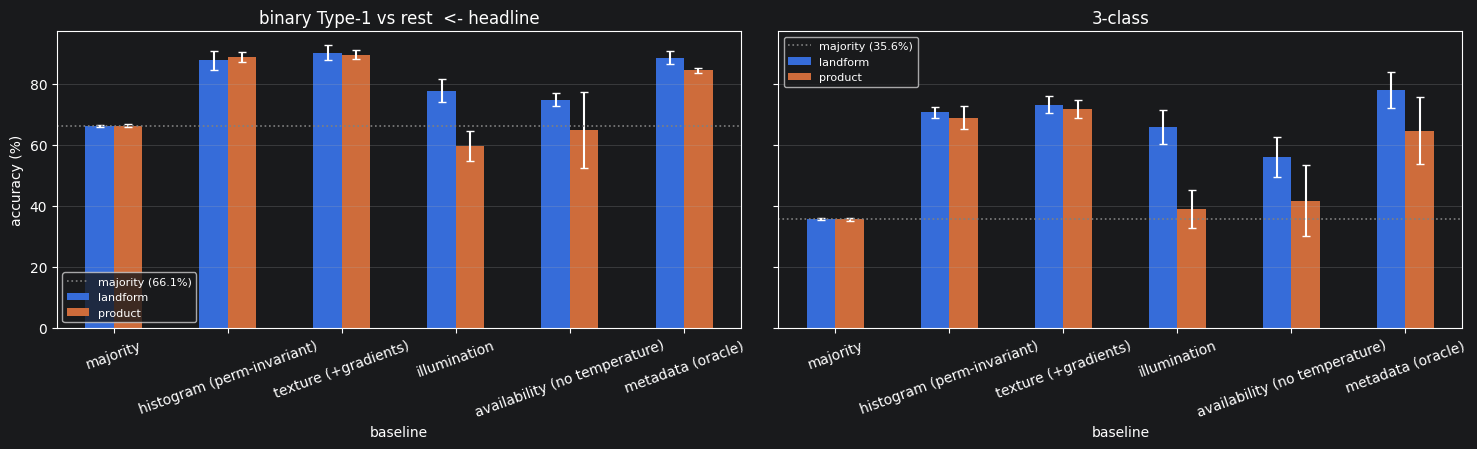

In [7]:
# Product-level is the honest column; landform-level is shown beside it so the
# leakage the product grouping removes is visible rather than assumed.
comparison = pd.DataFrame({
    f"{task_name} / {level}": table["acc_mean"] * 100
    for (level, task_name), table in baseline_tables.items()
}).round(1)
print("Accuracy (%), mean over 5 folds:")
display(comparison)

HEADLINE = "binary Type-1 vs rest" if TASK == "binary" else "3-class"
BAR = baseline_tables[("product", HEADLINE)].loc[
    "histogram (perm-invariant)", "acc_mean"]
print(f"Bar for the CNN on the {HEADLINE} task, product-level: "
      f"{BAR * 100:.1f}% accuracy, from pixel-shuffle-proof features alone.")

fig, axs = plt.subplots(1, 2, figsize=(15, 4.6), sharey=True)
for ax, task_name in zip(axs, TASK_LABELS):
    frame = pd.DataFrame({
        level: baseline_tables[(level, task_name)]["acc_mean"] * 100
        for level in ("landform", "product")
    })
    errs = pd.DataFrame({
        level: baseline_tables[(level, task_name)]["acc_std"] * 100
        for level in ("landform", "product")
    })
    frame.plot.bar(ax=ax, yerr=errs, capsize=3, rot=20)
    floor = baseline_tables[("product", task_name)].loc["majority", "acc_mean"] * 100
    ax.axhline(floor, ls=":", c="grey", lw=1.2, label=f"majority ({floor:.1f}%)")
    ax.set_title(task_name + ("  <- headline" if task_name == HEADLINE else ""))
    ax.set_ylabel("accuracy (%)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Reading the baselines

**1. Product-level grouping is not optional.** `illumination` scores 65.9% on
3-class with landform-level groups and **39.0%** with product-level groups,
against a 35.6% majority. Solar geometry is constant within a HiRISE product, so
under the looser grouping the classifier is not learning physics, it is
memorising which product a crop came from. The same collapse hits `metadata`
(78.0% -> 64.6%). The image features barely move (histogram 70.5% -> 68.9%),
which is the evidence that they are *not* leaking site identity.

**2. There is a mild but real illumination bias, and it should be disclosed.**
Median solar incidence is 43.1 deg for Type-1 against 55.2 deg for Type-4 and
51.7 deg for Type-2 (Kruskal-Wallis over the 159 products, p = 0.001).
Skylight candidates do tend to have been imaged with the sun higher -- plausibly
because that is what lets an observer see into them. It is not enough to predict
the class out-of-product, but it is not nothing.

**3. The bar is high, and highest exactly where the paper needs headroom.**
With product-level grouping:

| task | majority | histogram | texture |
|---|---|---|---|
| 3-class | 35.6% | 68.9% | 71.6% |
| **binary Type-1 vs rest** | **66.1%** | **88.7%** | **89.4%** |

A pixel-shuffled crop -- 22 numbers, no shape whatsoever -- separates skylights
from other pits at 88.7% accuracy, and a *linear* model on the same 22 numbers
reaches 87.8%, so this is not the gradient booster overfitting. Permutation
importance says the work is done by `p05` (how dark the darkest part of the crop
is) and `frac_above_0.7` (how much bright rim there is).

That is not an artefact, it is the class definition: Type-1 *is* an "almost
nonvisible bottom" inside an illuminated rim, which is precisely a bimodal
intensity histogram. Two consequences bind the paper:

* A CNN reporting ~90% here is **not** demonstrating that it understands
  morphology. It has to clear 88.7% by more than the fold-to-fold spread.
* The headroom left for a second modality is at most ~11 points, on 93
  independent skylight groups. Any thermal contribution has to be large to be
  visible -- which sharpens the argument the paper is making about data
  availability rather than weakening it.

## Single training run

A quick look, not a result. One hold-out leaves ~25 product groups in
validation, and the fold-to-fold spread is wider than most effects worth
measuring -- use the cross-validated ablation below for anything reported.

In [8]:
SINGLE_MODEL_TRAIN = False

# The binary task is imbalanced (34% skylights). Average precision, reported
# below, is threshold-free and unaffected; class weights only change where the
# argmax decision boundary sits.
CLASS_WEIGHTS = False

criterion = nn.CrossEntropyLoss()
if CLASS_WEIGHTS:
    counts = np.bincount(targets_all, minlength=N_CLASSES)
    weights = torch.tensor(counts.sum() / (N_CLASSES * counts), dtype=torch.float32)
    criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
    print("class weights:", [round(w, 3) for w in weights.tolist()])

if SINGLE_MODEL_TRAIN:
    lava_model = LavaTubeFinder(n_classes=N_CLASSES, modality="both")

    history = train_model(
        model=lava_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=torch.optim.Adam(lava_model.parameters(), lr=1e-4),
        scheduler=None,
        num_epochs=15,
        device=DEVICE,
    )

In [9]:
if SINGLE_MODEL_TRAIN:
    epochs = range(1, len(history["train_loss"]) + 1)
    metrics = ["loss", "acc", "precision", "recall", "f1"]
    titles = ["Loss", "Accuracy", "Precision", "Recall", "F1 (macro)"]

    fig, axs = plt.subplots(2, 3, figsize=(18, 9))
    for ax, metric, title in zip(axs.flatten(), metrics, titles):
        ax.plot(epochs, history[f"train_{metric}"], label="train", marker="o")
        ax.plot(epochs, history[f"val_{metric}"], label="validation", marker="o")
        ax.set_title(title)
        ax.set_xlabel("epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    axs.flatten()[-1].axis("off")
    plt.tight_layout()
    plt.show()

    if TASK == "binary":
        val_targets, val_probs = collect_predictions(lava_model, val_loader, DEVICE)
        binary_report(val_targets, val_probs, positive=POSITIVE)

## Cross-validated modality ablation

Train the same architecture on the optical crop alone, the thermal sequence
alone, and both.

**How to read it.**

* Splits are group-aware at **product** level, so no landform, no resolution
  replica and nothing sharing an acquisition can straddle a fold. That leaves
  127 groups.
* `collect_oof=True` predicts every sample exactly once, from the fold that did
  not train on it, so the confusion matrix below covers the whole data set
  rather than one fold.
* With `USE_REAL_THERMAL = False` the thermal sequence is `torch.randn`, so
  **"thermal" must land at the majority class and "both" must not beat
  "optical"**. Anything else is a bug, not a discovery. Run it that way once as
  a control before trusting any multimodal number.
* With real windows, read "both" against **two** floors: the `histogram`
  baseline, and the `availability` baseline above. Coverage correlates with
  location and location correlates with class, so a gain smaller than the
  availability lift is bookkeeping rather than physics. On the binary task that
  lift is currently -1.3 points, i.e. no leak; on 3-class it is +6.1.
* Expect the thermal contribution to be small. 302 of 314 sites carry a full
  three-frame sequence, but only 8% of the available observations fall in a
  local-time window where a diurnal amplitude can be measured at all -- the rest
  sit near the terminator, at both ends of the day.
* The bar is the `histogram` baseline above, not chance: **88.7% on binary,
  68.9% on 3-class**, both product-level.
* Each modality is cached to `model/cv_cache` as soon as it finishes, so a
  crash part-way through does not cost the modalities already done. Set
  `RUN_CV = True` and re-run; anything cached is loaded rather than retrained.

In [ ]:
CV_FOLDS = 5
CV_EPOCHS = 8
RUN_CV = True

# num_workers=0 on purpose. Windows spawns a fresh interpreter per worker, so a
# loader rebuilt each epoch pays that cost 240 times over a 3-modality
# ablation -- one of those spawns failing to allocate is what killed an earlier
# run. The GPU is the bottleneck at 384 px, so the workers buy almost nothing.
CV_WORKERS = 0

# Each modality is cached the moment it finishes. The full ablation is hours of
# compute; without this, a failure in the third modality throws away the first
# two. Delete a file to force that modality to re-run.
CV_CACHE = "model/cv_cache"
os.makedirs(CV_CACHE, exist_ok=True)

cv_results, cv_oof = {}, {}

for modality in ("optical", "thermal", "both"):
    stem = os.path.join(CV_CACHE, f"{TASK}_{modality}")

    if os.path.exists(stem + "_folds.json"):
        cv_results[modality] = pd.read_json(stem + "_folds.json")
        cached = np.load(stem + "_oof.npz")
        cv_oof[modality] = (cached["targets"], cached["probs"])
        print(f"{modality}: loaded from cache")
        continue

    if not RUN_CV:
        print(f"{modality}: not cached, and RUN_CV is False")
        continue

    print()
    print("#" * 65)
    print(f"# {modality}")
    print("#" * 65)

    # Skip decoding the crops entirely when they will not be used.
    factory = functools.partial(
        make_dataset, load_optical=(modality != "thermal")
    )

    per_fold, _, oof_targets, oof_probs = cross_validate(
        dataset_factory=factory,
        model_factory=functools.partial(
            LavaTubeFinder, n_classes=N_CLASSES, modality=modality
        ),
        criterion=criterion,
        optimizer_factory=lambda m: torch.optim.Adam(m.parameters(), lr=1e-4),
        num_epochs=CV_EPOCHS,
        device=DEVICE,
        n_splits=CV_FOLDS,
        batch_size=8,
        num_workers=CV_WORKERS,
        group_level="product",
        collect_oof=True,
    )

    per_fold.to_json(stem + "_folds.json")
    np.savez(stem + "_oof.npz", targets=oof_targets, probs=oof_probs)
    cv_results[modality] = per_fold
    cv_oof[modality] = (oof_targets, oof_probs)
    print(f"{modality}: cached to {stem}_*")

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


#################################################################
# optical
#################################################################
1846 samples in 127 product-level groups

--- fold 1/5 (1481 train / 365 val) ---
Starting training on device: cuda | modality: optical


Epoch 1/8 [train]:   0%|          | 0/186 [00:00<?, ?it/s]

Epoch 1/8 [val]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 01/08 [136.6s] - LR: 0.000100 | Train Loss: 0.3251 - Train Acc: 87.98% | Val Loss: 0.2197 - Val Acc: 93.97% | Val Precision: 0.9465 - Val Recall: 0.9197 - Val F1: 0.9311


Epoch 2/8 [train]:   0%|          | 0/186 [00:00<?, ?it/s]

...

Epoch 05/08 [107.7s] - LR: 0.000100 | Train Loss: 0.1805 - Train Acc: 94.70% | Val Loss: 0.1336 - Val Acc: 96.51% | Val Precision: 0.9601 - Val Recall: 0.9619 - Val F1: 0.9610


Epoch 6/8 [train]:   0%|          | 0/185 [00:00<?, ?it/s]

Epoch 6/8 [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 06/08 [108.8s] - LR: 0.000100 | Train Loss: 0.1498 - Train Acc: 95.72% | Val Loss: 0.4673 - Val Acc: 87.67% | Val Precision: 0.8586 - Val Recall: 0.8894 - Val F1: 0.8681


Epoch 7/8 [train]:   0%|          | 0/185 [00:00<?, ?it/s]

In [ ]:
if cv_results:
    metrics = ["val_acc", "val_precision", "val_recall", "val_f1"]

    table = pd.DataFrame({
        modality: {
            m.replace("val_", ""):
                f"{per_fold[m].mean() * 100:.1f} +/- {per_fold[m].std() * 100:.1f}"
            for m in metrics
        }
        for modality, per_fold in cv_results.items()
    }).T
    print(f"Mean +/- std across {CV_FOLDS} product-level folds:")
    display(table)

    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    means = pd.DataFrame({m: p[metrics].mean() for m, p in cv_results.items()}).T
    errs = pd.DataFrame({m: p[metrics].std() for m, p in cv_results.items()}).T
    means.plot.bar(yerr=errs, ax=axs[0], rot=0, capsize=3)
    axs[0].axhline(BAR, ls="--", c="crimson", lw=1.5,
                   label="histogram baseline ({:.1%})".format(BAR))
    axs[0].axhline(majority, ls=":", c="grey", lw=1,
                   label="majority ({:.1%})".format(majority))
    axs[0].set_title(f"Validation metrics, mean +/- std over {CV_FOLDS} folds")
    axs[0].legend(fontsize=8)
    axs[0].grid(alpha=0.3, axis="y")

    for modality, per_fold in cv_results.items():
        axs[1].scatter(per_fold.index, per_fold["val_f1"], label=modality, s=45)
    axs[1].axhline(BAR, ls="--", c="crimson", lw=1.5)
    axs[1].set_title("Per-fold F1 -- the spread is why a single split is not enough")
    axs[1].set_xlabel("fold")
    axs[1].set_ylabel("F1 (macro)")
    axs[1].legend()
    axs[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No cross-validation results yet -- set RUN_CV = True above.")

In [ ]:
# Out-of-fold detector readout: every sample scored by a model that never saw it.
if cv_oof and TASK == "binary":
    for modality, (oof_targets, oof_probs) in cv_oof.items():
        print()
        print(f"--- {modality} ---")
        binary_report(oof_targets, oof_probs, positive=POSITIVE)
elif cv_oof:
    from sklearn.metrics import classification_report, confusion_matrix

    names = [TASK_NAMES[i] for i in range(N_CLASSES)]
    for modality, (oof_targets, oof_probs) in cv_oof.items():
        predictions = oof_probs.argmax(1)
        print()
        print(f"--- {modality} ---")
        print(classification_report(oof_targets, predictions,
                                    target_names=names, digits=3))
        print(pd.DataFrame(confusion_matrix(oof_targets, predictions),
                           index=names, columns=names).to_string())
else:
    print("Run the cross-validation above with collect_oof=True first.")

## Next

1. **Region hold-out** -- train Tharsis, test Elysium -- as a generalisation test
   a random split cannot provide.
2. **Real thermal windows.** Two fixes first: the observation-id pattern that
   silently drops 32% of THEMIS products, and windows centred on a rounded grid
   point rather than on the landform.
3. **Synthetic-thermal GSD sweep** (100 -> 50 -> 20 -> 5 m) to find the
   resolution at which a thermal channel starts to contribute. That turns "the
   archive is not good enough" into an instrument requirement.